In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Dense,Flatten,InputLayer,BatchNormalization,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Layer
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Accuracy



In [2]:
splits = ['train[:80%]', 'train[80%:90%]', 'train[90%:]']

In [3]:
(train_ds, val_ds, test_ds), info = tfds.load(
    'malaria',
    split=splits,
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

In [4]:
for data in train_ds.take(3):
  print(data)

(<tf.Tensor: shape=(103, 103, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)
(<tf.Tensor: shape=(106, 121, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
       

In [5]:

# Check how many images in each split
train_count = tf.data.experimental.cardinality(train_ds).numpy()
val_count = tf.data.experimental.cardinality(val_ds).numpy()
test_count = tf.data.experimental.cardinality(test_ds).numpy()

print(f"Training images: {train_count}")   # Should be ~22,046
print(f"Validation images: {val_count}")   # Should be ~2,756
print(f"Testing images: {test_count}")     # Should be ~2,756


Training images: 22046
Validation images: 2756
Testing images: 2756


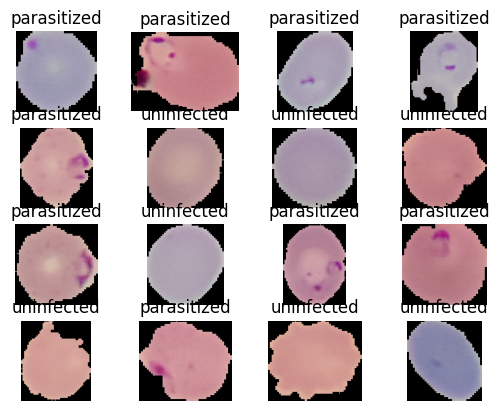

In [6]:
for i, (image,label) in enumerate(train_ds.take(16)):
  ax = plt.subplot(4,4, i + 1)
  plt.imshow(image)
  plt.title(info.features['label'].int2str(label))
  plt.axis('off')


In [7]:
info.features['label'].int2str(0)

'parasitized'

In [8]:
info.features['label'].int2str(1)

'uninfected'

In [9]:
# Preprocessing parameters
IMG_SIZE = 128
BATCH_SIZE = 32 

def preprocess(image, label):
    """Resize and normalize images"""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply preprocessing
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Batch, cache, and prefetch for performance
train_ds = train_ds.batch(BATCH_SIZE).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("Preprocessing complete!")
print(f"Image shape: {IMG_SIZE}x{IMG_SIZE}, Batch size: {BATCH_SIZE}")

Preprocessing complete!
Image shape: 128x128, Batch size: 32


In [10]:
# Data augmentation (applied only to training set)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

In [11]:
# Verify preprocessing - check a batch shape
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Min pixel: {tf.reduce_min(images):.4f}, Max pixel: {tf.reduce_max(images):.4f}")
    break

Batch shape: (32, 128, 128, 3)
Labels shape: (32,)
Min pixel: 0.0000, Max pixel: 0.9244


In [17]:
func_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
# First Convolutional Block
x = Conv2D(filters=6, kernel_size=3, strides=1, padding='valid', activation='relu')(func_input)
x = MaxPooling2D(pool_size=2, strides=2)(x)

# Second Convolutional Block
x = Conv2D(filters=16, kernel_size=3, strides=1, padding='valid', activation='relu')(x)
output = MaxPooling2D(pool_size=2, strides=2)(x)



# Create the model
feature_extractor_model = Model(inputs=func_input, outputs=output, name= 'feature_extractor')
feature_extractor_model.summary()
   

Model: "feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,048 (4.09 KB)

 Trainable params: 1,048 (4.09 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
func_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
x = feature_sub_classed(func_input)
# Flatten and Dense Layers
x = Flatten()(x)
x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation= 'relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation= 'sigmoid')(x)


# Create the model
model = Model(inputs=func_input, outputs=func_output, name= 'model')
model.summary()
   

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor_3             │ (None, 30, 30, 16)     │         1,488 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │     1,440,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,443,049 (5.50 MB)

 Trainable params: 1,442,781 (5.50 MB)

 Non-trainable params: 268 (1.05 KB)

In [13]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [14]:
# Train the model
EPOCHS = 10

# Add early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # callbacks=[early_stopping]
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6536 - loss: 0.6241 - val_accuracy: 0.5464 - val_loss: 0.7960
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7927 - loss: 0.4350 - val_accuracy: 0.9336 - val_loss: 0.3173
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9429 - loss: 0.1888 - val_accuracy: 0.9470 - val_loss: 0.1869
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9474 - loss: 0.1721 - val_accuracy: 0.9445 - val_loss: 0.2550
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9548 - loss: 0.1513 - val_accuracy: 0.9394 - val_loss: 0.2324
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9608 - loss: 0.1371 - val_accuracy: 0.9427 - val_loss: 0.2748
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9639 - loss: 0.1285 - val_accuracy: 0.9405 - val_loss: 0.2010
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9672 - loss: 0.1175 - val_accuracy: 

# Model Subclassing

In [25]:
class FeatureExtractor(Layer):
    def __init__(self, filters, kernel_size, strides, padding, activation, pool_size):
        super(FeatureExtractor, self).__init__()

        # First Convolutional Block - define layers, don't call them
        self.conv_1 = Conv2D(filters=filters, kernel_size=kernel_size, strides=strides, padding=padding, activation=activation)
        self.batch_1 = BatchNormalization()
        self.pool_1 = MaxPooling2D(pool_size=pool_size, strides=2*strides)

        # Second Convolutional Block
        self.conv_2 = Conv2D(filters=filters*2, kernel_size=kernel_size, strides=strides, padding=padding, activation=activation)
        self.batch_2 = BatchNormalization()  
        self.pool_2 = MaxPooling2D(pool_size=pool_size, strides=2*strides)  


    def call(self, x, training=False):
        x = self.conv_1(x)    
        x = self.batch_1(x, training=training)
        x = self.pool_1(x)

        x = self.conv_2(x)
        x = self.batch_2(x, training=training)  
        x = self.pool_2(x)

        return x
    
feature_sub_classed = FeatureExtractor(8, 3, 1, 'valid', 'relu', 2)

In [15]:
# Evaluate on test set
print("\n=== Test Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


=== Test Set Evaluation ===
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9536 - loss: 0.2110

Test Accuracy: 0.9536
Test Loss: 0.2110


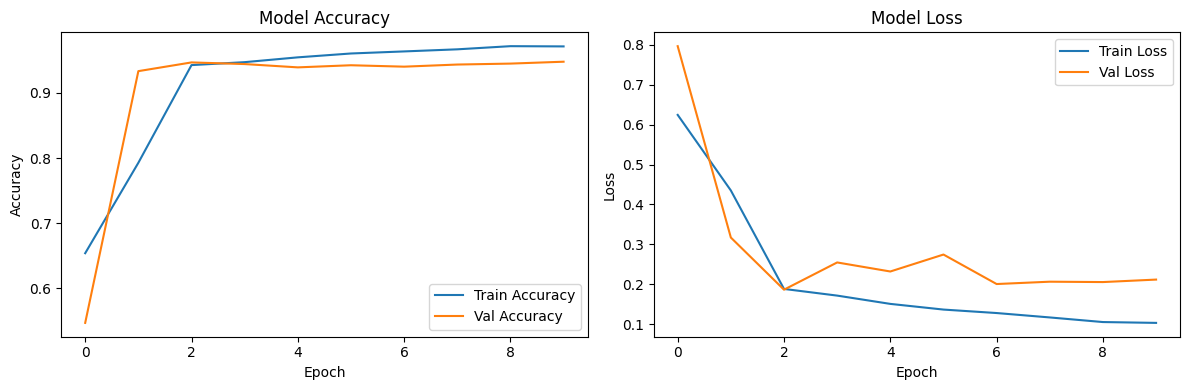

In [16]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


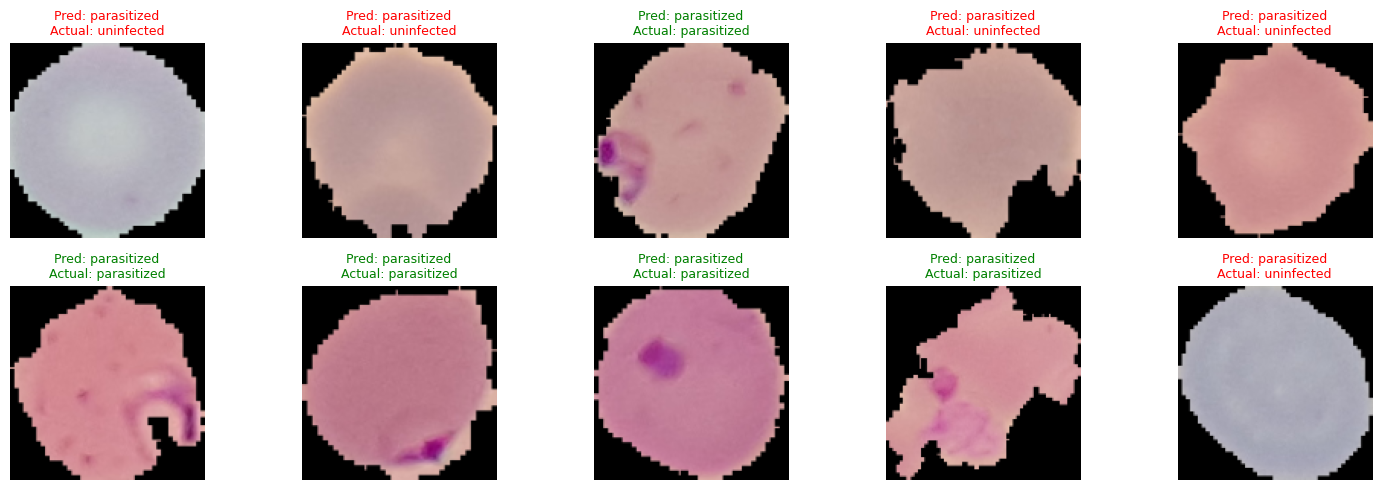

In [19]:
# Visualize predictions
plt.figure(figsize=(15, 5))

for i, (images, labels) in enumerate(test_ds.take(1)):
    predictions = model.predict(images)
    
    for j in range(10):
        plt.subplot(2, 5, j+1)
        plt.imshow(images[j])
        
        pred_label = np.argmax(predictions[j])
        actual_label = labels[j].numpy()
        
        color = 'green' if pred_label == actual_label else 'red'
        plt.title(f"Pred: {info.features['label'].int2str(pred_label)}\nActual: {info.features['label'].int2str(actual_label)}", 
                 color=color, fontsize=9)
        plt.axis('off')
    
    break

plt.tight_layout()
plt.show()

In [20]:
model.save("my_model.keras")

In [19]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

MessageError: User cancelled dfs_ephemeral authorization

In [ ]:
model.save("/content/drive/MyDrive/my_model.keras")

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/my_model.keras")

In [ ]:
!ls /content/drive/MyDrive/

'ABDUL BASIT.png'
'Black White Simple Photo Business Email Signature.png'
 Classroom
'Colab Notebooks'
'developing knowlwdge base using INSIGHT and EXPER....gsheet'
'facebook (1).png'
 facebook.png
 my_model.keras
'Red Modern Email Signature.png'
'Untitled document (1).gdoc'
'Untitled document.gdoc'
 vendor-sites.gsheet


In [ ]:
# Evaluate on test set
print("\n=== Test Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


=== Test Set Evaluation ===
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9460 - loss: 0.1847

Test Accuracy: 0.9452
Test Loss: 0.1834
